# exp10 — Uji terkontrol: *noise* dan guncangan permintaan

Notebook **pelapor**: membaca berkas hasil yang sudah ada, tidak melatih model,
tidak menulis ke `results/`, tidak mengimpor `src/experiments` maupun `tools`.

> **Dua ramalan pra-registrasi GAGAL** (P6a dan P9b). Keduanya diuji ulang di bagian 6
> dan dilaporkan apa adanya.

## 1. Ringkasan

**Pertanyaan yang dijawab.** RQ2, sumbu *gangguan terkendali*. Seluruh sumbu lain
memanfaatkan variasi yang **sudah ada** di dalam data. exp10 adalah satu-satunya yang
**memanipulasi** kondisi residual: dengan menyuntikkan *noise* ke Rossmann, kondisi residual
digeser dari "berstruktur" ke arah "*noise*" di bawah kendali kita, sementara segala hal
lain ditahan tetap.

Ini menjawab keterbatasan utama analisis kondisi residual: tiap kondisi diwakili oleh satu
*dataset*, sehingga kondisi itu tidak pernah dimanipulasi **di dalam** satu *dataset*.

**Ramalan pra-registrasi P6–P9** (ditulis 26 September 2026 sebelum skrip dijalankan sekali pun):

| | Isi | Hasil |
|---|---|---|
| P6a | Pangsa gerbang tertutup pada α = 0,50 ≥ pangsa pada data bersih | **GAGAL** |
| P6b | Pemburukan bergerbang ≤ 0,5% dan lebih kecil daripada tanpa gerbang | Terbukti |
| P7a–P7d | Respons Rossmann terhadap *noise* bertingkat | Terbukti (empat-empatnya) |
| P8a, P8b | Guncangan pada PharmaSales | Terbukti |
| P9a | Guncangan Rossmann: AR-LRX-Aug unggul atas S₁ | Terbukti |
| P9b | Guncangan Rossmann: tidak kalah >2% dari XGBoost | **GAGAL** |

**Dipakai di mana.**

| Naskah | Bagian |
|---|---|
| Disertasi | Subbab 5.7, **Tabel 5.10**, **Tabel 5.11**, **Tabel 5.12**, **Gambar 5.5** |
| Paper IJIES | **tidak dipakai** — dijalankan setelah naskah ronde 2 dikirim |

## 2. Lingkungan

In [1]:
# Notebook pelapor: HANYA MEMBACA.
# Tidak melatih model, tidak mengimpor src/experiments atau tools (agar TensorFlow
# tidak ikut termuat), dan tidak pernah menulis ke results/, data/ atau raw/.
%matplotlib inline
from pathlib import Path
import ast, json, hashlib, datetime, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def cari_root(p: Path) -> Path:
    for c in [p, *p.parents]:
        if (c / "results").is_dir() and (c / "src" / "experiments").is_dir():
            return c
    raise RuntimeError("root repositori tidak ditemukan dari " + str(p))


ROOT = cari_root(Path.cwd().resolve())
RES = ROOT / "results"

pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 95)
pd.set_option("display.max_rows", 200)

print("Root repositori :", ROOT)
print("Folder hasil    :", RES.relative_to(ROOT),
      f"({sum(1 for f in RES.rglob('*') if f.is_file())} berkas)")
print("Dijalankan      :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))


def idn(x, d=2, tanda=False):
    """Format angka gaya Indonesia (koma desimal, titik ribuan)."""
    s = f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    if tanda and x > 0:
        s = "+" + s
    return s.replace("-", "\u2212")


def baca(nama, **kw):
    """Baca satu berkas di results/ sebagai DataFrame. Read-only."""
    f = RES / nama
    if not f.exists():
        raise FileNotFoundError(f"{nama} tidak ada di results/")
    return pd.read_csv(f, **kw)


def potongan(relpath, nama=None, awal=None, akhir=None):
    """Tampilkan potongan kode dengan membaca berkas sebagai TEKS.

    Memakai ``ast`` untuk menemukan batas fungsi/konstanta, sehingga modul
    eksperimen tidak perlu diimpor.
    """
    f = ROOT / relpath
    teks = f.read_text(encoding="utf-8")
    baris = teks.splitlines()
    if nama is not None:
        pohon = ast.parse(teks)
        ketemu = False
        for n in ast.walk(pohon):
            if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)) and n.name == nama:
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
            if isinstance(n, ast.Assign) and any(getattr(t, "id", None) == nama for t in n.targets):
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
        if not ketemu:
            raise KeyError(f"'{nama}' tidak ditemukan di {relpath}")
    awal = awal or 1
    akhir = akhir or len(baris)
    lebar = len(str(akhir))
    print(f"--- {relpath}:{awal}-{akhir} " + "-" * max(0, 74 - len(relpath)))
    for i in range(awal, akhir + 1):
        print(f"{str(i).rjust(lebar)} | {baris[i - 1]}")


def git(*args):
    """Jalankan perintah git read-only di root repositori."""
    try:
        r = subprocess.run(["git", *args], cwd=ROOT, capture_output=True, text=True, timeout=30)
        return r.stdout.strip() if r.returncode == 0 else ""
    except Exception:
        return ""


def asal(nama_meta=None, berkas_hasil=None, skrip=None, log=None):
    """Cetak asal-usul: meta.json, commit, dan log run bila ada."""
    if nama_meta:
        f = RES / nama_meta
        if f.exists():
            print("meta.json " + "-" * 60)
            print(json.dumps(json.loads(f.read_text(encoding="utf-8")), indent=2, ensure_ascii=False))
            print()
    for label, path in [("berkas hasil", berkas_hasil), ("skrip", skrip)]:
        if path:
            print(f"commit terakhir yang menyentuh {label} ({path})")
            print("  " + (git("log", "-1", "--date=short", "--format=%h  %ad  %s", "--", path) or "(tidak terbaca)"))
    if log:
        f = RES / "logs" / log
        print()
        if f.exists():
            print(f"results/logs/{log}  ({f.stat().st_size} bytes, "
                  f"ditulis {datetime.datetime.fromtimestamp(f.stat().st_mtime):%Y-%m-%d %H:%M})")
        else:
            print(f"results/logs/{log} tidak ada di klon ini (berkas *.log diabaikan git).")

Root repositori : I:\Shared drives\Riset S3\Experiment S3 Code\antgravity_riset\AR-LRX_hybrid-forecasting


Folder hasil    : results (179 berkas)
Dijalankan      : 2026-09-29 06:40


In [2]:
# Pembanding angka CSV terhadap angka yang tercetak di disertasi.
# Tidak ada angka yang dibetulkan di sini; ketidakcocokan hanya dilaporkan.
_cek = []


def cek(butir, nilai_csv, nilai_naskah, tol=0.005, d=4, rujukan=""):
    beda = abs(float(nilai_csv) - float(nilai_naskah))
    ok = beda <= tol
    _cek.append({
        "Butir": butir,
        "Rujukan naskah": rujukan,
        "Dari CSV": round(float(nilai_csv), d),
        "Di disertasi": float(nilai_naskah),
        "|selisih|": round(beda, 6),
        "Status": "COCOK" if ok else "TIDAK COCOK",
    })
    return ok


def laporan_cek():
    t = pd.DataFrame(_cek)
    n_ok = int((t.Status == "COCOK").sum())
    display(t)
    print()
    print(f"RINGKASAN: {n_ok} dari {len(t)} angka COCOK dengan naskah disertasi.")
    buruk = t[t.Status == "TIDAK COCOK"]
    if len(buruk):
        print()
        print("!" * 78)
        print("ADA ANGKA YANG TIDAK COCOK. Tidak dibetulkan di notebook ini.")
        print("Laporkan butir berikut sebelum notebook dipakai sebagai lampiran:")
        for _, r in buruk.iterrows():
            print(f"  - {r.Butir} ({r['Rujukan naskah']}): "
                  f"CSV {r['Dari CSV']} vs naskah {r['Di disertasi']}")
        print("!" * 78)
    else:
        print("Tidak ada selisih di luar toleransi pembulatan.")
    return t

## 3. Desain eksperimen

**Kontrak C1–C8 tidak diubah.** Gangguan dikenakan pada **permintaan mentah**, sebelum
fitur dibentuk, sehingga seluruh pipeline sesudahnya berjalan apa adanya.

Parameter rancangan dikunci di muka pada pra-registrasi dan tidak disetel:

In [3]:
potongan("tools/exp10_controlled_perturbation.py", awal=77, akhir=86)

--- tools/exp10_controlled_perturbation.py:77-86 ------------------------------------
77 | ALPHAS = [0.10, 0.25, 0.50]
78 | PH_REPS = 2
79 | SPIKE, LEVEL = 1.5, 1.3
80 | ROSS_STORE_SHARE = 0.25
81 | SHOCK_SEED = 2026
82 | VARIANT = "V3_sales_lagged"
83 | CATEGORIES = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
84 | GRANS = [("daily", "data/raw/pharma-sales/salesdaily.csv", 7),
85 |          ("weekly", "data/raw/pharma-sales/salesweekly.csv", 52)]
86 | 


**Skenario**, dibaca sebagai teks dari skripnya:

In [4]:
potongan("tools/exp10_controlled_perturbation.py", nama="scenarios")

--- tools/exp10_controlled_perturbation.py:97-103 ------------------------------------
 97 | def scenarios():
 98 |     out = [("clean", None, None, 0)]
 99 |     for a in ALPHAS:
100 |         for r in range(1, PH_REPS + 1):
101 |             out.append((f"noise_a{a:.2f}_r{r}", "noise", a, r))
102 |     out += [("spike", "spike", SPIKE, 0), ("level", "level", LEVEL, 0)]
103 |     return out


**Dua jenis gangguan.**

1. ***Noise*** — derau proporsional dengan tingkat α ∈ {0,10; 0,25; 0,50}, dua realisasi
   untuk PharmaSales dan satu untuk Rossmann. Tujuannya menggeser kondisi residual.
2. **Guncangan permintaan** — lonjakan (faktor 1,5) dan pergeseran level (faktor 1,3) pada
   jendela tertentu di **blok uji**, mengenai 25% toko Rossmann (*seed* 2026). Tujuannya
   menguji perilaku di bawah kejadian yang tidak terlihat saat pelatihan.

**Dua cara penilaian pada Rossmann.** Prediksi dinilai terhadap target yang **teramati**
(sudah terganggu) dan terhadap target **bersih** yang belum terganggu. Yang pertama adalah
angka utama; yang kedua eksploratif.

**Seed gangguan dipisahkan dari seed model**, sehingga realisasi derau dapat direproduksi
tanpa menyentuh determinisme model:

In [5]:
potongan("tools/exp10_controlled_perturbation.py", nama="seed_of")

--- tools/exp10_controlled_perturbation.py:88-89 ------------------------------------
88 | def seed_of(*parts) -> int:
89 |     return zlib.crc32("|".join(map(str, parts)).encode()) % (2 ** 31)


## 4. Asal-usul hasil

In [6]:
RUN_EXPERIMENT = False

PERINTAH = [
    "python tools/exp10_controlled_perturbation.py --part pharma",
    "python tools/exp10_controlled_perturbation.py --part rossmann",
    "python tools/exp10_controlled_perturbation.py --part summary",
]

if RUN_EXPERIMENT:
    for c in PERINTAH:
        print(">>", c)
        r = subprocess.run(c, shell=True, cwd=ROOT)
        print("   kode keluar:", r.returncode)
else:
    print("RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.")
    print()
    print("Perintah asli yang menghasilkan berkas di results/:")
    for c in PERINTAH:
        print("   ", c)
    print()
    print('Runtime asli: PharmaSales sekitar 1-1,5 jam, Rossmann sekitar 3 jam, ringkasan beberapa detik. Setiap bagian menyimpan checkpoint baris demi baris dan melanjutkan dari titik berhenti bila terputus.')

RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.

Perintah asli yang menghasilkan berkas di results/:
    python tools/exp10_controlled_perturbation.py --part pharma
    python tools/exp10_controlled_perturbation.py --part rossmann
    python tools/exp10_controlled_perturbation.py --part summary

Runtime asli: PharmaSales sekitar 1-1,5 jam, Rossmann sekitar 3 jam, ringkasan beberapa detik. Setiap bagian menyimpan checkpoint baris demi baris dan melanjutkan dari titik berhenti bila terputus.


In [7]:
asal(berkas_hasil="results/exp10_summary_rossmann.csv",
     skrip="tools/exp10_controlled_perturbation.py",
     log="exp10_rossmann.log")
print()
print("Pra-registrasi:")
print("  " + (git("log", "-1", "--date=format:%Y-%m-%d %H:%M:%S",
                  "--format=%h  %ad  %s", "--", "PREREG_exp10_exp13_exp14.md") or "-"))
print("Hasil:")
print("  " + (git("log", "-1", "--date=format:%Y-%m-%d %H:%M:%S",
                  "--format=%h  %ad  %s", "--", "results/exp10_pharma.csv") or "-"))

commit terakhir yang menyentuh berkas hasil (results/exp10_summary_rossmann.csv)


  3a642df  2026-09-26  Results of pre-registered exp10, exp13, exp14
commit terakhir yang menyentuh skrip (tools/exp10_controlled_perturbation.py)


  b913709  2026-09-26  Pre-register exp10, exp13, exp14: design and predictions P4-P9

results/logs/exp10_rossmann.log  (2660 bytes, ditulis 2026-09-26 12:22)

Pra-registrasi:


  b913709  2026-09-26 08:27:13  Pre-register exp10, exp13, exp14: design and predictions P4-P9
Hasil:


  3a642df  2026-09-26 19:11:35  Results of pre-registered exp10, exp13, exp14


## 5. Hasil

### 5.1 PharmaSales — Tabel 5.10

In [8]:
sp10 = baca("exp10_summary_pharma.csv").set_index("scenario")
sr10 = baca("exp10_summary_rossmann.csv").set_index("scenario")

LAB = {"clean": "Bersih", "noise_a0.10": "Noise a=0,10", "noise_a0.25": "Noise a=0,25",
       "noise_a0.50": "Noise a=0,50", "spike": "Lonjakan", "level": "Pergeseran level"}
t510 = pd.DataFrame({
    "Skenario": [LAB[k] for k in sp10.index],
    "n baris": sp10.n_rows.values,
    "Gerbang tertutup (pangsa)": sp10.gate_closed_share.round(2).values,
    "R2res median": sp10.resid_val_r2_median.round(3).values,
    "Bergerbang vs S1 (%)": sp10.gated_mean_change_vs_S1_pct.round(2).values,
    "  n memburuk": sp10.gated_n_worse.values,
    "Tanpa gerbang vs S1 (%)": sp10.ungated_mean_change_vs_S1_pct.round(2).values,
    "  n memburuk": sp10.ungated_n_worse.values,
    "AR-LRX vs XGBoost (%)": sp10.pooled_arlrx_vs_xgb_pct.round(2).values,
    "Baris terdampak: vs XGBoost (%)": sp10.shock_pooled_arlrx_vs_xgb_pct.round(2).values,
})
display(t510)

,Skenario,n baris,Gerbang tertutup (pangsa),R2res median,Bergerbang vs S1 (%),n memburuk,Tanpa gerbang vs S1 (%),AR-LRX vs XGBoost (%),Baris terdampak: vs XGBoost (%)
0,Bersih,32,0.53,-0.107,0.22,19,1.77,-1.63,NaN
1,"Noise a=0,10",64,0.44,-0.099,0.28,54,2.55,-2.89,NaN
2,"Noise a=0,25",64,0.64,-0.091,0.04,41,1.07,-1.48,NaN
3,"Noise a=0,50",64,0.48,-0.102,0.14,54,1.83,-2.17,NaN
4,Lonjakan,32,0.53,-0.107,0.27,20,2.51,-4.00,-4.44
5,Pergeseran level,32,0.53,-0.107,0.20,21,0.96,-1.07,-0.89


### 5.2 Rossmann — Tabel 5.11

In [9]:
A = "AR-LRX-Aug [structural]"
LABR = {"clean": "Bersih", "noise_a0.10_r1": "Noise a=0,10", "noise_a0.25_r1": "Noise a=0,25",
        "noise_a0.50_r1": "Noise a=0,50", "spike": "Lonjakan", "level": "Pergeseran level"}
t511 = pd.DataFrame({
    "Skenario": [LABR[k] for k in sr10.index],
    "RMSE uji": sr10[f"orig_RMSE:{A}"].round(2).values,
    "vs S1 (%)": sr10[f"orig_RMSE:{A} vs S1 [structural] (%)"].round(2).values,
    "vs XGBoost (%)": sr10[f"orig_RMSE:{A} vs XGBoost (%)"].round(2).values,
    "vs LightGBM (%)": sr10[f"orig_RMSE:{A} vs LightGBM (Zeng) (%)"].round(2).values,
    "w*": sr10.gate_w.round(2).values,
    "R2res validasi": sr10.resid_val_r2.round(3).values,
    "Terdampak: vs XGBoost (%)": sr10[f"shock_orig_RMSE:{A} vs XGBoost (%)"].round(2).values,
    "Terdampak: vs S1 (%)": sr10[f"shock_orig_RMSE:{A} vs S1 [structural] (%)"].round(2).values,
})
display(t511)
print()
print("Skenario bersih mereproduksi angka utama Bab IV: RMSE uji",
      idn(sr10.loc["clean", f"orig_RMSE:{A}"], 2))

,Skenario,RMSE uji,vs S1 (%),vs XGBoost (%),vs LightGBM (%),w*,R2res validasi,Terdampak: vs XGBoost (%),Terdampak: vs S1 (%)
0,Bersih,954.90,-23.03,-6.18,-5.45,0.9,0.238,NaN,NaN
1,"Noise a=0,10",1026.35,-20.30,-6.08,-5.45,0.9,0.206,NaN,NaN
2,"Noise a=0,25",1337.75,-11.98,-5.42,-4.65,1.0,0.159,NaN,NaN
3,"Noise a=0,50",2105.47,-4.39,-4.46,-3.49,1.0,0.068,NaN,NaN
4,Lonjakan,1047.67,-24.21,-4.89,-4.08,0.9,0.238,3.43,-29.90
5,Pergeseran level,1154.45,-27.98,-1.07,0.99,0.9,0.238,8.15,-33.33



Skenario bersih mereproduksi angka utama Bab IV: RMSE uji 954,90


### 5.3 Gambar 5.5

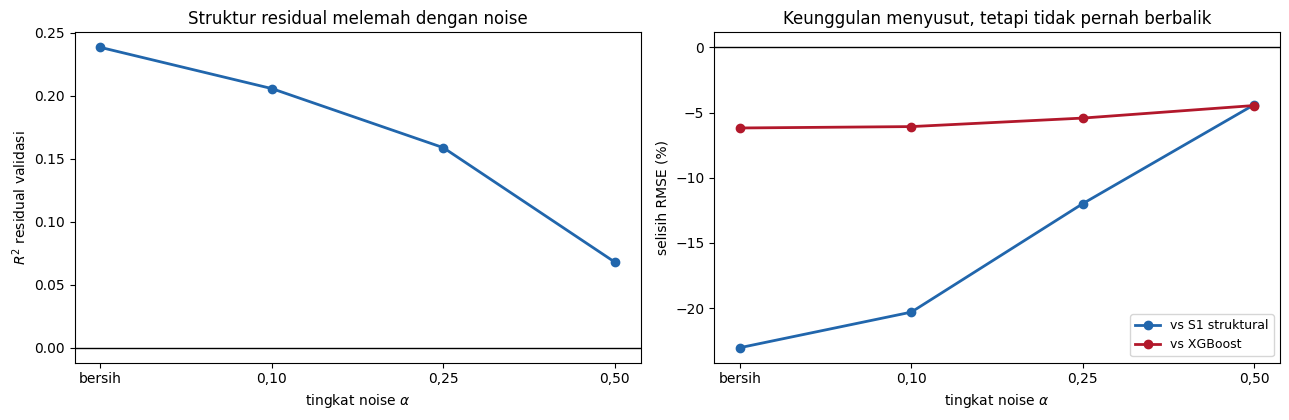

In [10]:
urut = ["clean", "noise_a0.10_r1", "noise_a0.25_r1", "noise_a0.50_r1"]
x = np.arange(len(urut))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

axes[0].plot(x, sr10.loc[urut, "resid_val_r2"], "o-", color="#2166ac", lw=2)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xticks(x); axes[0].set_xticklabels(["bersih", "0,10", "0,25", "0,50"])
axes[0].set_xlabel("tingkat noise $\\alpha$")
axes[0].set_ylabel("$R^2$ residual validasi")
axes[0].set_title("Struktur residual melemah dengan noise")

for kol, lab, w in [(f"orig_RMSE:{A} vs S1 [structural] (%)", "vs S1 struktural", "#2166ac"),
                    (f"orig_RMSE:{A} vs XGBoost (%)", "vs XGBoost", "#b2182b")]:
    axes[1].plot(x, sr10.loc[urut, kol], "o-", color=w, lw=2, label=lab)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(["bersih", "0,10", "0,25", "0,50"])
axes[1].set_xlabel("tingkat noise $\\alpha$")
axes[1].set_ylabel("selisih RMSE (%)")
axes[1].set_title("Keunggulan menyusut, tetapi tidak pernah berbalik")
axes[1].legend(fontsize=9)
fig.tight_layout(); plt.show()

## 6. Pengujian ulang ramalan P6–P9

Setiap ramalan dihitung ulang dari CSV persis seperti bunyinya di
`PREREG_exp10_exp13_exp14.md`, bukan disalin dari kesimpulan.

In [11]:
# Setiap ramalan P6-P9 diuji ulang persis seperti bunyinya di PREREG.
hasil = []


def uji(kode, bunyi, terpenuhi, teramati):
    hasil.append({"Ramalan": kode, "Bunyi (ringkas)": bunyi, "Teramati": teramati,
                  "Hasil": "Terbukti" if terpenuhi else "GAGAL"})


# P6a
p6a = sp10.loc["noise_a0.50", "gate_closed_share"] >= sp10.loc["clean", "gate_closed_share"]
uji("P6a", "Pangsa gerbang tertutup pada a=0,50 >= pangsa pada run bersih", p6a,
    f'{sp10.loc["noise_a0.50","gate_closed_share"]:.2f} vs {sp10.loc["clean","gate_closed_share"]:.2f}')

# P6b
ns = ["noise_a0.10", "noise_a0.25", "noise_a0.50"]
g = sp10.loc[ns, "gated_mean_change_vs_S1_pct"]
u = sp10.loc[ns, "ungated_mean_change_vs_S1_pct"]
uji("P6b", "Bergerbang <= +0,5% pada setiap a, dan lebih kecil daripada tanpa gerbang",
    bool((g <= 0.5).all() and (g < u).all()),
    " / ".join(f"{v:.2f}" for v in g) + "% vs " + " / ".join(f"{v:.2f}" for v in u) + "%")

# P7a
r7 = sr10.loc[urut, "resid_val_r2"]
uji("P7a", "R2res Rossmann turun monoton terhadap noise", bool((r7.diff().dropna() < 0).all()),
    " -> ".join(f"{v:.3f}" for v in r7))

# P7b
d7 = sr10.loc[urut, f"orig_RMSE:{A} vs S1 [structural] (%)"]
uji("P7b", "Keunggulan atas S1 menyusut monoton", bool((d7.diff().dropna() > 0).all()),
    " -> ".join(f"{v:.2f}" for v in d7) + "%")

# P7c
uji("P7c", "Tidak pernah lebih buruk dari S1 lebih dari 0,5%", bool((d7 <= 0.5).all()),
    "selalu lebih akurat" if (d7 < 0).all() else f"maksimum {d7.max():.2f}%")

# P7d
sub = ["noise_a0.10_r1", "noise_a0.25_r1"]
xg = sr10.loc[sub, f"orig_RMSE:{A} vs XGBoost (%)"]
lg = sr10.loc[sub, f"orig_RMSE:{A} vs LightGBM (Zeng) (%)"]
uji("P7d", "Pada a <= 0,25 tetap lebih akurat daripada XGBoost dan LightGBM",
    bool((xg < 0).all() and (lg < 0).all()),
    " / ".join(f"{v:.2f}" for v in xg) + "% dan " + " / ".join(f"{v:.2f}" for v in lg) + "%")

# P8a, P8b
sh = ["spike", "level"]
p8a = sp10.loc[sh, "shock_pooled_arlrx_vs_xgb_pct"]
p8b = sp10.loc[sh, "shock_pooled_arlrx_vs_S1_pct"]
uji("P8a", "Guncangan PharmaSales, baris terdampak: AR-LRX lebih akurat daripada XGBoost",
    bool((p8a < 0).all()), " ; ".join(f"{v:.2f}" for v in p8a) + "%")
uji("P8b", "Guncangan PharmaSales, baris terdampak: AR-LRX vs S1 <= +2%",
    bool((p8b <= 2).all()), " ; ".join(f"{v:+.2f}" for v in p8b) + "%")

# P9a, P9b
p9a = sr10.loc[sh, f"shock_orig_RMSE:{A} vs S1 [structural] (%)"]
p9b = sr10.loc[sh, f"shock_orig_RMSE:{A} vs XGBoost (%)"]
uji("P9a", "Guncangan Rossmann, baris terdampak: AR-LRX-Aug lebih akurat daripada S1",
    bool((p9a < 0).all()), " ; ".join(f"{v:.2f}" for v in p9a) + "%")
uji("P9b", "Guncangan Rossmann, baris terdampak: AR-LRX-Aug tidak kalah >2% dari XGBoost",
    bool((p9b <= 2).all()), " ; ".join(f"{v:+.2f}" for v in p9b) + "%")

t512 = pd.DataFrame(hasil)
display(t512)
n_gagal = int((t512.Hasil == "GAGAL").sum())
print()
print(f"{len(t512)} ramalan exp10 diuji ulang: {len(t512)-n_gagal} terbukti, {n_gagal} GAGAL.")
print("Yang gagal: " + ", ".join(t512[t512.Hasil == "GAGAL"].Ramalan) + ".")
print("Keduanya dilaporkan apa adanya di RESULTS_exp10_exp13_exp14.md dan Tabel 5.12.")

,Ramalan,Bunyi (ringkas),Teramati,Hasil
0,P6a,"Pangsa gerbang tertutup pada a=0,50 >= pangsa pada run bersih",0.48 vs 0.53,GAGAL
1,P6b,"Bergerbang <= +0,5% pada setiap a, dan lebih kecil daripada tanpa gerbang",0.28 / 0.04 / 0.14% vs 2.55 / 1.07 / 1.83%,Terbukti
2,P7a,R2res Rossmann turun monoton terhadap noise,0.238 -> 0.206 -> 0.159 -> 0.068,Terbukti
3,P7b,Keunggulan atas S1 menyusut monoton,-23.03 -> -20.30 -> -11.98 -> -4.39%,Terbukti
4,P7c,"Tidak pernah lebih buruk dari S1 lebih dari 0,5%",selalu lebih akurat,Terbukti
5,P7d,"Pada a <= 0,25 tetap lebih akurat daripada XGBoost dan LightGBM",-6.08 / -5.42% dan -5.45 / -4.65%,Terbukti
6,P8a,"Guncangan PharmaSales, baris terdampak: AR-LRX lebih akurat daripada XGBoost",-4.44 ; -0.89%,Terbukti
7,P8b,"Guncangan PharmaSales, baris terdampak: AR-LRX vs S1 <= +2%",+0.49 ; +0.32%,Terbukti
8,P9a,"Guncangan Rossmann, baris terdampak: AR-LRX-Aug lebih akurat daripada S1",-29.90 ; -33.33%,Terbukti
9,P9b,"Guncangan Rossmann, baris terdampak: AR-LRX-Aug tidak kalah >2% dari XGBoost",+3.43 ; +8.15%,GAGAL



10 ramalan exp10 diuji ulang: 8 terbukti, 2 GAGAL.
Yang gagal: P6a, P9b.
Keduanya dilaporkan apa adanya di RESULTS_exp10_exp13_exp14.md dan Tabel 5.12.


## 7. Cek kecocokan dengan angka disertasi

Acuannya adalah draf v3_5. Pada draf sebelumnya, Tabel 5.12 baris P8b menulis `+0,33%`
untuk skenario pergeseran level, sedangkan `exp10_summary_pharma.csv` menyimpan `0,3250%`
yang dibulatkan menjadi `0,32%`. Selisih itu ditemukan saat notebook ini disusun, lalu
dikoreksi pada v3_5 dan pada `RESULTS_exp10_exp13_exp14.md` dengan erratum bertanggal.
Vonis P8b tidak berubah, karena ambangnya +2%.

In [12]:
# --- Tabel 5.12 disertasi ---------------------------------------------------
NASKAH = {"P4a": "Terbukti", "P4b": "Terbukti", "P5a": "Gagal (harian)", "P5b": "Gagal",
          "P6a": "Gagal", "P6b": "Terbukti", "P7a": "Terbukti", "P7b": "Terbukti",
          "P7c": "Terbukti", "P7d": "Terbukti", "P8a": "Terbukti", "P8b": "Terbukti",
          "P9a": "Terbukti", "P9b": "Gagal"}
t = t512.set_index("Ramalan")
for k in ["P6a", "P6b", "P7a", "P7b", "P7c", "P7d", "P8a", "P8b", "P9a", "P9b"]:
    naskah_gagal = NASKAH[k].startswith("Gagal")
    csv_gagal = t.loc[k, "Hasil"] == "GAGAL"
    cek(f"Tabel 5.12 {k}: vonis", int(csv_gagal), int(naskah_gagal), tol=0, rujukan="Tabel 5.12")

# --- Nilai teramati pada Tabel 5.12 -----------------------------------------
cek("Tabel 5.12 P6a: pangsa pada a=0,50", sp10.loc["noise_a0.50", "gate_closed_share"], 0.48,
    tol=0.005, rujukan="Tabel 5.12")
cek("Tabel 5.12 P6a: pangsa pada run bersih", sp10.loc["clean", "gate_closed_share"], 0.53,
    tol=0.005, rujukan="Tabel 5.12")
for a, v in zip(ns, [0.28, 0.04, 0.14]):
    cek(f"Tabel 5.12 P6b: bergerbang {a} (%)", sp10.loc[a, "gated_mean_change_vs_S1_pct"], v,
        tol=0.005, rujukan="Tabel 5.12")
for a, v in zip(ns, [2.55, 1.07, 1.83]):
    cek(f"Tabel 5.12 P6b: tanpa gerbang {a} (%)", sp10.loc[a, "ungated_mean_change_vs_S1_pct"], v,
        tol=0.005, rujukan="Tabel 5.12")
for s, v in zip(urut, [0.238, 0.206, 0.159, 0.068]):
    cek(f"Tabel 5.12 P7a: R2res {s}", sr10.loc[s, "resid_val_r2"], v, tol=0.0006, rujukan="Tabel 5.12")
for s, v in zip(urut, [-23.03, -20.30, -11.98, -4.39]):
    cek(f"Tabel 5.12 P7b: vs S1 {s} (%)", sr10.loc[s, f"orig_RMSE:{A} vs S1 [structural] (%)"], v,
        tol=0.005, rujukan="Tabel 5.12")
for s, v in zip(sub, [-6.08, -5.42]):
    cek(f"Tabel 5.12 P7d: vs XGBoost {s} (%)", sr10.loc[s, f"orig_RMSE:{A} vs XGBoost (%)"], v,
        tol=0.005, rujukan="Tabel 5.12")
for s, v in zip(sub, [-5.45, -4.65]):
    cek(f"Tabel 5.12 P7d: vs LightGBM {s} (%)", sr10.loc[s, f"orig_RMSE:{A} vs LightGBM (Zeng) (%)"], v,
        tol=0.005, rujukan="Tabel 5.12")
for s, v in zip(sh, [-4.44, -0.89]):
    cek(f"Tabel 5.12 P8a: {s} (%)", sp10.loc[s, "shock_pooled_arlrx_vs_xgb_pct"], v,
        tol=0.005, rujukan="Tabel 5.12")
for s, v in zip(sh, [0.49, 0.32]):
    cek(f"Tabel 5.12 P8b: {s} (%)", sp10.loc[s, "shock_pooled_arlrx_vs_S1_pct"], v,
        tol=0.005, rujukan="Tabel 5.12")
for s, v in zip(sh, [-29.90, -33.33]):
    cek(f"Tabel 5.12 P9a: {s} (%)", sr10.loc[s, f"shock_orig_RMSE:{A} vs S1 [structural] (%)"], v,
        tol=0.005, rujukan="Tabel 5.12")
for s, v in zip(sh, [3.43, 8.15]):
    cek(f"Tabel 5.12 P9b: {s} (%)", sr10.loc[s, f"shock_orig_RMSE:{A} vs XGBoost (%)"], v,
        tol=0.005, rujukan="Tabel 5.12")

# --- Tabel 5.11: skenario bersih mereproduksi angka utama Bab IV -------------
cek("Tabel 5.11: RMSE skenario bersih = angka utama Bab IV",
    sr10.loc["clean", f"orig_RMSE:{A}"], 954.90, tol=0.005, rujukan="Tabel 5.11 / Tabel 4.8")

# --- Prosa Subbab 5.7 -------------------------------------------------------
# Klaim berbentuk pertidaksamaan, bukan kesamaan: diuji sebagai benar/salah.
_max_gated = sp10.loc[ns, "gated_mean_change_vs_S1_pct"].max()
cek("Subbab 5.7.1: rata-rata perubahan bergerbang tetap di bawah 0,3% (1 = benar)",
    int(_max_gated < 0.3), 1, tol=0, rujukan="Subbab 5.7.1")
print(f"   (nilai maksimumnya {_max_gated:.4f}%, jadi klaim 'di bawah 0,3%' terpenuhi)")
cek("Subbab 5.7.2: w* pada a=0,50", sr10.loc["noise_a0.50_r1", "gate_w"], 1.0,
    tol=0.005, rujukan="Subbab 5.7.2")

hasil_cek = laporan_cek()

print()
print("CATATAN ERRATUM P8b")
v = sp10.loc["level", "shock_pooled_arlrx_vs_S1_pct"]
print(f"Nilai skenario pergeseran level di CSV adalah {v:.6f}%, yang dibulatkan")
print(f"dua desimal menjadi {v:.2f}%. Draf disertasi sebelum v3_5 dan versi awal")
print("RESULTS_exp10_exp13_exp14.md menulis 0,33%. Keduanya sudah dikoreksi;")
print("erratum bertanggal tercatat di RESULTS_exp10_exp13_exp14.md.")
print("Vonis P8b tidak berubah, karena ambangnya +2%.")

   (nilai maksimumnya 0.2836%, jadi klaim 'di bawah 0,3%' terpenuhi)


,Butir,Rujukan naskah,Dari CSV,Di disertasi,|selisih|,Status
0,Tabel 5.12 P6a: vonis,Tabel 5.12,1.0000,1.000,0.000000,COCOK
1,Tabel 5.12 P6b: vonis,Tabel 5.12,0.0000,0.000,0.000000,COCOK
2,Tabel 5.12 P7a: vonis,Tabel 5.12,0.0000,0.000,0.000000,COCOK
3,Tabel 5.12 P7b: vonis,Tabel 5.12,0.0000,0.000,0.000000,COCOK
4,Tabel 5.12 P7c: vonis,Tabel 5.12,0.0000,0.000,0.000000,COCOK
5,Tabel 5.12 P7d: vonis,Tabel 5.12,0.0000,0.000,0.000000,COCOK
6,Tabel 5.12 P8a: vonis,Tabel 5.12,0.0000,0.000,0.000000,COCOK
7,Tabel 5.12 P8b: vonis,Tabel 5.12,0.0000,0.000,0.000000,COCOK
8,Tabel 5.12 P9a: vonis,Tabel 5.12,0.0000,0.000,0.000000,COCOK
9,Tabel 5.12 P9b: vonis,Tabel 5.12,1.0000,1.000,0.000000,COCOK



RINGKASAN: 41 dari 41 angka COCOK dengan naskah disertasi.
Tidak ada selisih di luar toleransi pembulatan.

CATATAN ERRATUM P8b
Nilai skenario pergeseran level di CSV adalah 0.324966%, yang dibulatkan
dua desimal menjadi 0.32%. Draf disertasi sebelum v3_5 dan versi awal
RESULTS_exp10_exp13_exp14.md menulis 0,33%. Keduanya sudah dikoreksi;
erratum bertanggal tercatat di RESULTS_exp10_exp13_exp14.md.
Vonis P8b tidak berubah, karena ambangnya +2%.


## 8. Interpretasi dan keterbatasan

**Rossmann: kondisi residual dapat digeser, dan gerbang mengikutinya sebagian.**
*Noise* bertingkat melemahkan struktur residual sesuai ramalan. R²res validasi turun monoton
dari 0,238 ke 0,206, 0,159, dan 0,068, sementara keunggulan AR-LRX atas tahap pertama
strukturalnya menyusut monoton dari −23,03% ke −4,39%. Yang terbaca adalah hubungan
dosis–respons di dalam satu *dataset*, dengan satu realisasi *noise*. Rancangan ini tidak
mengisolasi penyebabnya, sehingga tidak mendukung klaim kausal (Subbab 5.7.2 dan 5.8.4).

**Tetapi *noise* yang diuji belum cukup untuk membalikkan kesimpulan.** R²res tetap positif
pada α = 0,50, gerbang tetap terbuka, dan AR-LRX tidak pernah lebih buruk daripada tahap
pertamanya. Jadi exp10 menunjukkan arah pergeseran, bukan titik baliknya.

**P6a gagal.** Pangsa gerbang tertutup pada α = 0,50 adalah 0,48, tidak lebih besar daripada
pada data bersih yang 0,53. Polanya juga tidak monoton: 0,53 pada data bersih, 0,44 pada
α = 0,10, 0,64 pada α = 0,25, dan 0,48 pada α = 0,50. Hasil ini membatasi klaim tentang
gerbang, yang tidak dapat disebut sebagai detektor tingkat *noise*.

**P9b gagal.** Pada baris yang terdampak guncangan di Rossmann, AR-LRX-Aug tertinggal dari
XGBoost sebesar +3,43% (lonjakan) dan +8,15% (pergeseran level) — melampaui ambang 2% yang
dipra-registrasikan. Tahap pertama struktural memakai rata-rata per kelompok yang ditaksir
pada data latih, sehingga pergeseran level pada blok uji tidak terwakili.

**Keterbatasan.**

1. Satu realisasi derau untuk Rossmann (dua untuk PharmaSales) — variabilitas antar-realisasi
   tidak terukur pada Rossmann.
2. Bentuk gangguan (derau proporsional, lonjakan, pergeseran level) dipilih di muka dan
   sempit; permintaan nyata dapat terganggu dengan cara lain.
3. Tiga tingkat α tidak mencapai titik balik kondisi residual, sehingga batas rezimnya tidak
   terukur.
4. Guncangan hanya dikenakan pada blok uji, bukan pada data latih.

## 9. Pertanyaan yang mungkin diajukan promotor

**1. "Kondisi residual itu hanya label pasca-hoc. Apa yang ditambahkan exp10?"**
Pada eksperimen lain kondisi residual hanya diamati, sedangkan di sini besarnya *noise*
diatur. *Noise* disuntikkan ke permintaan mentah Rossmann dengan segala hal lain ditahan
tetap, dan R²res turun monoton (0,238 → 0,068) bersamaan dengan menyusutnya keunggulan
AR-LRX (−23,03% → −4,39%). Yang diperoleh adalah hubungan dosis–respons di dalam satu
*dataset*, dengan satu realisasi *noise*. Rancangan ini tidak mengisolasi penyebabnya,
sehingga saya tidak mengklaim hubungan kausal. Batas itu dinyatakan pada Subbab 5.7.2 dan
5.8.4.

**2. "Dua ramalan gagal. Apa artinya bagi tesis?"**
Keduanya membatasi klaim dengan cara yang spesifik dan sudah masuk naskah. P6a menunjukkan
gerbang tidak berfungsi sebagai detektor tingkat *noise*; perannya sebagai pelindung
terhadap pemburukan tetap didukung P6b. P9b menunjukkan batas tahap pertama struktural di
bawah pergeseran level pada data uji. Pada kondisi residual *noise*, AR-LRX tetap mengalami
pemburukan kecil terhadap tahap pertamanya: rata-rata 0,28%, 0,04%, dan 0,14% pada tiga
tingkat α (P6b).

**3. "Mengapa gerbang lebih jarang tertutup pada *noise* tertinggi?"**
Dugaan saya, gerbang dipilih pada RMSE validasi, dan *noise* juga mengotori data validasi,
sehingga perbaikan validasi semu lebih mungkin muncul. Mekanisme ini belum diuji terpisah.
Perlu dicatat bahwa polanya tidak monoton: pangsa gerbang tertutup adalah 0,53 pada data
bersih, 0,44 pada α = 0,10, 0,64 pada α = 0,25, dan 0,48 pada α = 0,50.

**4. "Apakah skenario bersih exp10 cocok dengan hasil utama Bab IV?"**
Ya, dan itu diperiksa di bagian 7: RMSE uji skenario bersih pada Rossmann adalah 954,90 —
angka yang sama dengan Tabel 4.8. Kalau tidak cocok, berarti ada yang berubah di pipeline
antara Bab IV dan exp10.

**5. "Bagaimana guncangan dibuat, dan apakah bisa direproduksi?"**
Faktor lonjakan 1,5 dan pergeseran level 1,3, pada jendela yang ditetapkan di docstring
skrip, mengenai 25% toko yang dipilih dengan *seed* 2026. Seluruh parameter itu dikunci pada
pra-registrasi. *Seed* gangguan dipisahkan dari *seed* model lewat fungsi `seed_of` (bagian 3),
sehingga realisasi derau dapat direproduksi tanpa mengganggu determinisme model.